In [1]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default='browser'
import pyarrow.feather as feather
import plotly.express as px
import numpy as np


In [2]:
#density_data = pd.read_csv("Data/cluster_0_data.csv", low_memory=False) # Kevitsa
#enterprise_data = feather.read_feather("C:/Users/lin236/OneDrive - CSIRO/Minerals4D/Projects/SandS_DS/Parker Challenge 2025/Enterprise_pre2010_Desurvey.csv")
PC2025_data = pd.read_csv("C:/Users/lin236/Documents/MEC_PC_Data/CSIRO Share/Export 19032024/Multi_Element_Composites.csv", low_memory=False) # Kevitsa

In [8]:
# select domain
# Select rows where the value in the 'domain' column is equal to 'target_value'

filtered_samples = PC2025_data[PC2025_data['MINDOM'] == 'A']


#filtered_samples = df.dropna(subset=['Alt1_Code', 'Alt2_Code', 'Density_gcm3'])
#filtered_samples = df.dropna(subset=['Au_ppm', 'As_ppm_BESTEL', 'Hg_ppm_BESTEL'])
#filtered_samples = filtered_samples.iloc[::2] # Randomly select half of the samples

sample_count = len(filtered_samples)


#print(f"Number of samples with alteration and Density_gcm3 data: {sample_count}")
print(f"Number of samples with gold and pathfinder data: {sample_count}")



Number of samples with gold and pathfinder data: 1219


In [12]:
# log transform the data
plot_samples = filtered_samples[['EAST', 'NORTH', 'RL', 'Au_ppm']]
plot_samples['log_Au_ppm'] = np.log(filtered_samples['Au_ppm'])

# Create 3D scatter plot
fig = px.scatter_3d(plot_samples, \
                    x='EAST', y='NORTH', z='RL', \
                        color='log_Au_ppm', size='Au_ppm', \
                        opacity=0.7, labels={'log_Au_ppm': 'Gold log(ppm)'})

fig.update_traces(marker=dict(line=dict(width=0)))
# Show plot
fig.show()

C:\Users\lin236\AppData\Local\Temp\ipykernel_32588\3851781695.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [34]:
mineral = 'Au_ppm'
#filter = ['Sulph1_Code', 'Sulph1_Pct', 'Sulph2_Code', 'Sulph2_Pct']
#deposit_data = density_data

#deposit_data = deposit_data.dropna(subset=[mineral] + filter)
deposit_data = filtered_samples
#df1 = deposit_data
df1 = filtered_samples
variable = mineral

In [35]:
## one-hot encode geology

encoded_deposit_data = pd.get_dummies(deposit_data, columns=['GEOLOGY'], prefix='GEOLOGY')

encoded_deposit_data.head()

,holeid,from,to,INTERVAL (ft),UNIQUE_ID,SAMPLETYPE,MINDOM,Au_ppm,Ag_ppm_BESTEL,Al_pct_BESTEL,...,Yb_ppm_BESTEL,Zn_ppm_BESTEL,Zr_ppm_BESTEL,EAST,NORTH,RL,GEOLOGY_DSO,GEOLOGY_Drc,GEOLOGY_SDb,GEOLOGY_Tc
134,BD-171,670.0,675.0,5.0,BD-171_670_675,RC,A,0.605,1.1,0.539,...,0.45,139.0,1.63,-2518.294914,32599.961854,5134.863535,0,1,0,0
135,BD-171,675.0,680.0,5.0,BD-171_675_680,RC,A,1.883,1.4,0.539,...,0.45,139.0,1.63,-2517.539581,32599.839240,5129.922453,0,1,0,0
136,BD-171,680.0,685.0,5.0,BD-171_680_685,RC,A,2.091,2.4,0.535,...,0.32,16.5,1.88,-2516.778401,32599.708236,5124.982472,0,0,1,0
137,BD-171,685.0,690.0,5.0,BD-171_685_690,RC,A,1.717,3.7,0.535,...,0.32,16.5,1.88,-2516.017220,32599.577233,5120.042492,0,0,1,0
138,BD-171,690.0,695.0,5.0,BD-171_690_695,RC,A,2.262,5.3,0.535,...,0.32,16.5,1.88,-2515.256040,32599.446230,5115.102511,0,0,1,0


In [26]:
#two_composite_1covariates = deposit_data

#missing_percentage = (two_composite_1covariates.isnull().sum() / len(two_composite_1covariates)) * 100

#variables_to_remove = missing_percentage[missing_percentage > 5].index

#two_composite_1covariates = two_composite_1covariates.drop(columns=variables_to_remove)

'''
encoded_data = deposit_data.copy()

threshold = 10

for column in two_composite_1covariates.columns:
    if two_composite_1covariates[column].dtype == 'object':
        unique_values = two_composite_1covariates[column].nunique()
        
        if unique_values <= threshold:
            encoded_columns = pd.get_dummies(encoded_data[column], prefix=column)
            encoded_columns = encoded_columns.astype(int)  
            encoded_data = pd.concat([encoded_data, encoded_columns], axis=1)
            encoded_data = encoded_data.drop(columns=[column])




encoded_columns = [col for col in encoded_data.columns if '_Code_' in col]

total_columns = []

for col in encoded_columns:
    prefix, original_column = col.split('_Code_')
    
    total_column = f"{original_column}_Total"
    total_columns.append(total_column)
    
    encoded_data[total_column] = (
        encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]
    )

total_columns = []

category_totals = {}

for col in encoded_columns:
    prefix, original_column = col.split('_Code_')
    
    total_column = f"{original_column}_Total"
    if total_column not in total_columns:
        total_columns.append(total_column)
    
    total_values = encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]
    
    if total_column in category_totals:
        category_totals[total_column] += total_values
    else:
        category_totals[total_column] = total_values

for total_column, total_values in category_totals.items():
    encoded_data[total_column] = total_values
'''

'\nencoded_data = deposit_data.copy()\n\nthreshold = 10\n\nfor column in two_composite_1covariates.columns:\n    if two_composite_1covariates[column].dtype == \'object\':\n        unique_values = two_composite_1covariates[column].nunique()\n        \n        if unique_values <= threshold:\n            encoded_columns = pd.get_dummies(encoded_data[column], prefix=column)\n            encoded_columns = encoded_columns.astype(int)  \n            encoded_data = pd.concat([encoded_data, encoded_columns], axis=1)\n            encoded_data = encoded_data.drop(columns=[column])\n\n\n\n\nencoded_columns = [col for col in encoded_data.columns if \'_Code_\' in col]\n\ntotal_columns = []\n\nfor col in encoded_columns:\n    prefix, original_column = col.split(\'_Code_\')\n    \n    total_column = f"{original_column}_Total"\n    total_columns.append(total_column)\n    \n    encoded_data[total_column] = (\n        encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]\n    )

In [36]:
all_variable_names = encoded_deposit_data.columns.tolist()

In [ ]:
#filtered_encoded_data = encoded_deposit_data[encoded_deposit_data.columns.intersection(variable_names+ ['Density_gcm3', 'Name'])]

deposit_data = encoded_deposit_data[['Au_ppm', 'As_ppm_BESTEL', 'Hg_ppm_BESTEL', 'Tl_ppm_BESTEL', 'Te_ppm_BESTEL', 'GEOLOGY_Drc', 'GEOLOGY_DSO', 'GEOLOGY_SDb', 'GEOLOGY_Tc', 'EAST', 'NORTH', 'RL']]


deposit_data.describe()
#deposit_data.fillna(0, inplace=True)
deposit_data



,Au_ppm,As_ppm_BESTEL,Hg_ppm_BESTEL,Tl_ppm_BESTEL,Te_ppm_BESTEL,GEOLOGY_Drc,GEOLOGY_DSO,GEOLOGY_SDb,GEOLOGY_Tc,EAST,NORTH,RL
134,0.605,553.0,2.26,1.65,0.11,1,0,0,0,-2518.294914,32599.961854,5134.863535
135,1.883,553.0,2.26,1.65,0.11,1,0,0,0,-2517.539581,32599.839240,5129.922453
136,2.091,126.0,2.40,0.48,0.78,0,0,1,0,-2516.778401,32599.708236,5124.982472
137,1.717,126.0,2.40,0.48,0.78,0,0,1,0,-2516.017220,32599.577233,5120.042492
138,2.262,126.0,2.40,0.48,0.78,0,0,1,0,-2515.256040,32599.446230,5115.102511
...,...,...,...,...,...,...,...,...,...,...,...,...
7557,0.692,92.3,0.90,0.68,0.06,0,0,1,0,-2988.819885,33357.593762,4821.677411
7558,0.230,92.3,0.90,0.68,0.06,0,0,1,0,-2988.852316,33357.221863,4816.691375
7559,0.199,849.0,0.36,0.45,0.09,0,0,1,0,-2988.884746,33356.849965,4811.705339
7560,0.127,849.0,0.36,0.45,0.09,0,0,1,0,-2988.917177,33356.478066,4806.719303


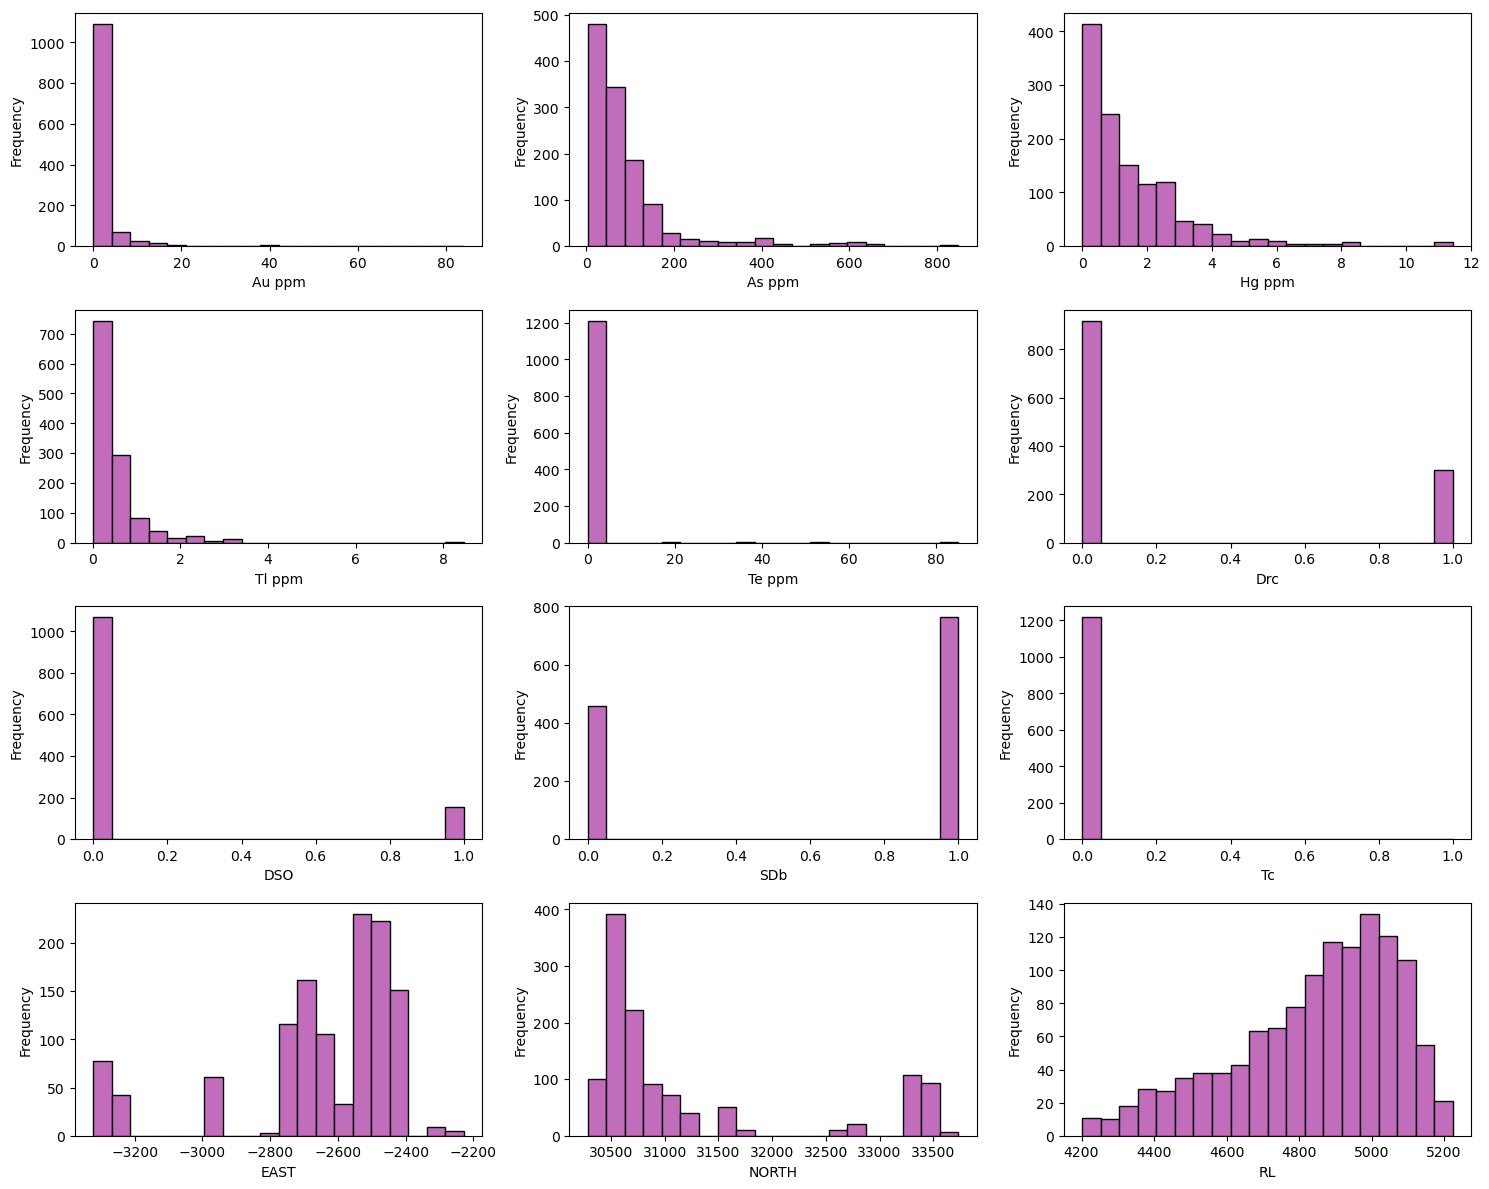

In [49]:
variables = deposit_data.columns.tolist()

variables2 = ['Au ppm', 'As ppm', 'Hg ppm', 'Tl ppm', 'Te ppm', 'Drc', 'DSO', 'SDb', 'Tc', 'EAST', 'NORTH', 'RL']
fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))

for i, var in enumerate(variables):
    row = i // 3
    col = i % 3
    axs[row, col].hist(deposit_data[var], bins=20, color='#C26DBC', edgecolor='black')
    axs[row, col].set_xlabel(str(variables2[i]))
    axs[row, col].set_ylabel('Frequency')
    axs[row, col].grid(False)
    if var == 'X':
        x_ticks = axs[row, col].get_xticks()
        x_ticks = x_ticks[::1]  
        axs[row, col].set_xticks(x_ticks)

plt.tight_layout()
plt.show()


In [50]:
plot_samples = deposit_data.copy()
plot_samples['Log_Au_ppm'] = np.log(deposit_data['Au_ppm'])
plot_samples['Log_As_ppm_BESTEL'] = np.log(deposit_data['As_ppm_BESTEL'])
plot_samples['Log_Hg_ppm_BESTEL'] = np.log(deposit_data['Hg_ppm_BESTEL'])
plot_samples['Log_Tl_ppm_BESTEL'] = np.log(deposit_data['Tl_ppm_BESTEL'])
plot_samples['Log_Te_ppm_BESTEL'] = np.log(deposit_data['Te_ppm_BESTEL'])



c:\Users\lin236\Anaconda3\envs\Loop\lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning:

divide by zero encountered in log



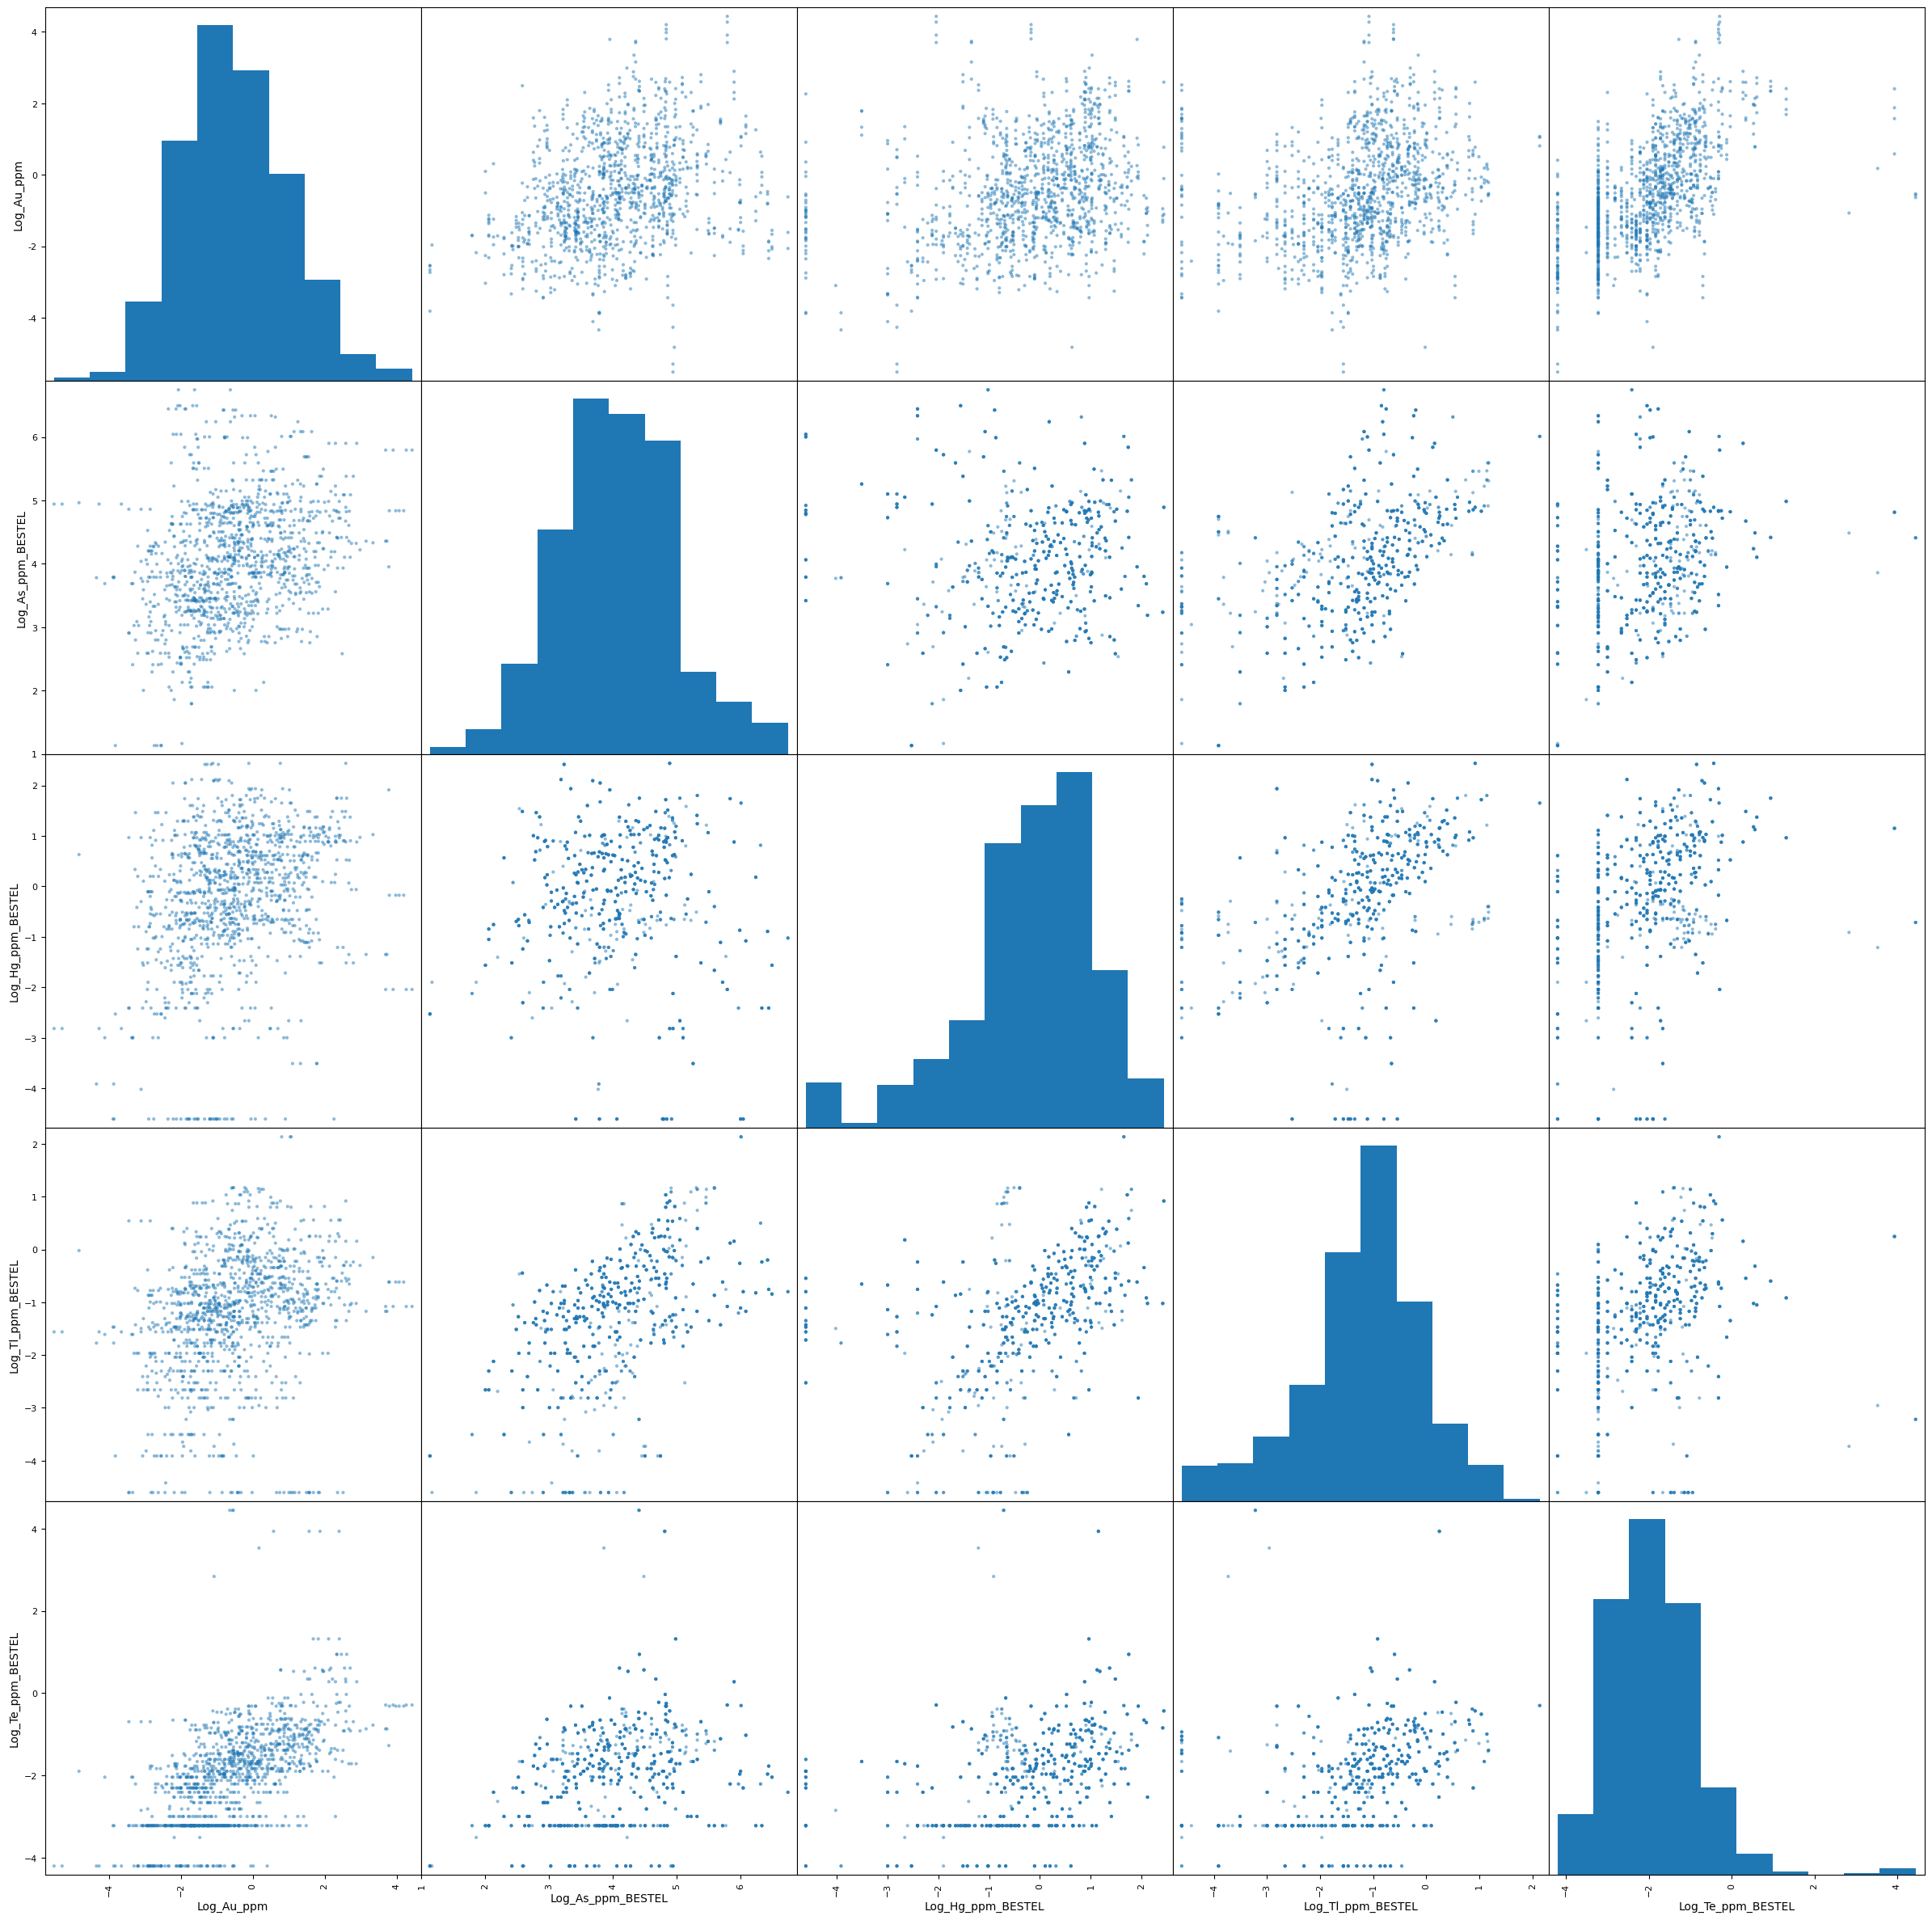

In [42]:


columns = ['Log_Au_ppm', 'Log_As_ppm_BESTEL', 'Log_Hg_ppm_BESTEL', 'Log_Tl_ppm_BESTEL', 'Log_Te_ppm_BESTEL']
cleaned_data = plot_samples[columns].replace([np.inf, -np.inf], np.nan).dropna()
scatter_matrix = pd.plotting.scatter_matrix(cleaned_data[columns], figsize=(30, 30))


#import seaborn as sns

# columns = ['X', 'Y', 'Z', 'CP_Total', 'PO_Total', 'PY_Total', 'RQD_Pct', 'Cr_ppm', 'Density_gcm3']
# sns.pairplot(deposit_data[columns], diag_kind='kde', corner=True)

In [14]:
summary = deposit_data.describe().round(3)

latex_table = summary.to_latex()

C:\Users\lin236\AppData\Local\Temp\ipykernel_18116\2957715656.py:3: FutureWarning:

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.



In [51]:
deposit_data.to_csv('C:/Users/lin236/Documents/MEC_PC_Data/CSIRO Share/Export 19032024/Output/filtered_unnormalised_deposit_data.csv', index=False)


In [52]:
columns_to_normalize = ['EAST', 'NORTH', 'RL']   

min_values = deposit_data[columns_to_normalize].min()

for column in columns_to_normalize:
    deposit_data[column] = deposit_data[column] - min_values[column]

# Calculate the minimum and maximum values from all three variables
min_values = deposit_data[columns_to_normalize].min().min()
max_values = deposit_data[columns_to_normalize].max().max()

for column in columns_to_normalize:
    deposit_data[column] = (deposit_data[column] - min_values) / (max_values - min_values)

# Rename scaled spatial coords as X, Y, Z
deposit_data.rename(columns={'EAST': 'X', 'NORTH': 'Y', 'RL': 'Z'}, inplace=True)


#Scale the rest of the covariates in their own scale
covariates = ['As_ppm_BESTEL', 'Hg_ppm_BESTEL', 'Tl_ppm_BESTEL', 'Te_ppm_BESTEL']
scaler = MinMaxScaler()
deposit_data.loc[:, [mineral] +covariates] = scaler.fit_transform(deposit_data.loc[:,[mineral] + covariates])


C:\Users\lin236\AppData\Local\Temp\ipykernel_32588\635443113.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\lin236\AppData\Local\Temp\ipykernel_32588\635443113.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\lin236\AppData\Local\Temp\ipykernel_32588\635443113.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view

In [53]:
all_indexes = deposit_data.index
all_indexes.to_series().to_csv('C:/Users/lin236/Documents/MEC_PC_Data/CSIRO Share/Export 19032024/Output/indexes.csv', index=False)


In [54]:
deposit_data.to_csv('C:/Users/lin236/Documents/MEC_PC_Data/CSIRO Share/Export 19032024/Output/filtered_deposit_data.csv', index=False)
